# Fed-SSL cross-device — pré-treino federado vs baseline FedAvg

Notebook **somente de leitura**. Não treina, não escreve em `results/`.

Lê `results/fedssl_cross_device_parts/` (os parciais por job) e **nunca** o consolidado
`fedssl_cross_device.csv` — o driver só consolida no fim da grade, então durante a
execução o consolidado contém a grade anterior.

**Cada análise aqui é um gráfico**; as tabelas vêm depois, como conferência.

⚠️ **F7 em aberto:** a seleção few-shot usa o split de validação **cheio** mesmo quando
o treino tem 1 rótulo por classe. Mantido por fidelidade ao Minerva/da Luz; é ponto de
revisão prioritário (`docs/metodo_e_auditoria.md`). Nada aqui corrige isso.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PART_DIR = PROJECT_ROOT / 'results' / 'fedssl_cross_device_parts'
BASE_CSV = PROJECT_ROOT / 'results' / 'fed_cross_device.csv'
SL_TRANSFER = PROJECT_ROOT / 'results' / 'supervised_eval_transfer.csv'

# Cores: slots 1-3 do palette de referencia, em ordem FIXA por metodo (nunca ciclada;
# a cor segue a entidade, nao a posicao). Os tres primeiros slots sao os que validam
# no pairlist all-pairs, que e o caso de small multiples.
CM = {'none': '#2a78d6', 'tfc': '#eb6834', 'lfr': '#1baf7a'}
LABEL = {'none': 'FedAvg supervisionado', 'tfc': 'TF-C federado', 'lfr': 'LFR federado'}
POS, NEG = '#2a78d6', '#e34948'      # diverging: sinal importa
INK, INK2 = '#1a1a19', '#5c5b55'

ENCODERS = ['resnetse5', 'cnnpff', 'rnn', 'tstcc']
METHODS = ['none', 'tfc', 'lfr']
SSL = ['tfc', 'lfr']
SHOTS = ['1', '2', '5', '10']
ALL_SHOTS = SHOTS + ['full']
IN_SPEC = {'RealWorld_thigh': 'device:RealWorld_thigh:10',
           'MotionSense': 'device:MotionSense:10'}
C55 = 'device:RealWorld_thigh+MotionSense:5+5'
C1010 = 'device:RealWorld_thigh+MotionSense:10+10'
ARM = {'device:RealWorld_thigh:10': 'in10-RW', 'device:MotionSense:10': 'in10-MS',
       C55: 'cross5+5', C1010: 'cross10+10'}
KEY = ['method', 'encoder', 'spec', 'seed', 'n_shots']
PLATEAU = 20

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.edgecolor': '#c9c8c2',
                     'axes.labelcolor': INK2, 'text.color': INK,
                     'xtick.color': INK2, 'ytick.color': INK2,
                     'grid.color': '#e8e7e2', 'font.size': 9,
                     'legend.frameon': False})

def style(ax, axis='y'):
    ax.grid(axis=axis, lw=0.6)
    ax.set_axisbelow(True)
    return ax

## 2. Cobertura — o que ainda não existe

Vem antes de qualquer número: uma célula incompleta some da média sem avisar, e a média
fica parecendo comparável quando não é.

896 parciais, 204,600 linhas, R=150


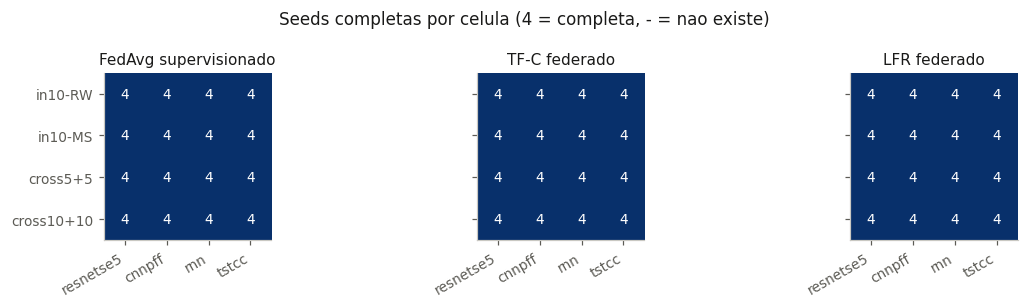

Todas as celulas completas.


In [2]:
files = sorted(PART_DIR.glob('*.csv'))
raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
raw['n_shots'] = raw['n_shots'].astype(str)
RMAX = int(raw['round'].max())
print(f'{len(files)} parciais, {len(raw):,} linhas, R={RMAX}')

cov = (raw[KEY].drop_duplicates().groupby(['method', 'encoder', 'spec'])['seed']
       .nunique().rename('seeds').reset_index())

fig, axes = plt.subplots(1, 3, figsize=(11, 2.8), sharey=True)
for ax, m in zip(axes, METHODS):
    d = (cov[cov.method == m].pivot_table(index='spec', columns='encoder',
                                          values='seeds')
         .reindex(index=list(ARM), columns=ENCODERS))
    ax.imshow(d.values.astype(float), cmap='Blues', vmin=0, vmax=4)
    for i in range(d.shape[0]):
        for j in range(d.shape[1]):
            v = d.values[i, j]
            ax.text(j, i, '-' if pd.isna(v) else f'{int(v)}', ha='center',
                    va='center', fontsize=9,
                    color='white' if (0 if pd.isna(v) else v) > 2 else INK)
    ax.set_xticks(range(len(ENCODERS)))
    ax.set_xticklabels(ENCODERS, rotation=30, ha='right')
    ax.set_yticks(range(len(ARM)))
    ax.set_yticklabels(list(ARM.values()))
    ax.set_title(LABEL[m], fontsize=10, color=INK)
    ax.grid(False)
fig.suptitle('Seeds completas por celula (4 = completa, - = nao existe)', fontsize=11)
fig.tight_layout(); plt.show()

inc = cov[cov.seeds < 4]
print('CELULAS INCOMPLETAS — nao comparar:' if len(inc) else 'Todas as celulas completas.')
if len(inc):
    display(inc)

## 3. Qual rodada reportar — e por que não é o `argmax`

Cada run treina 150 rodadas e é avaliado depois de **cada uma**. Para reportar um número
por run é preciso escolher uma rodada.

**O problema do `argmax(val_acc)`:** se a curva é um platô com ruído por cima, "o ponto
mais alto" é só *onde o ruído calhou de ser maior* — não é um pico real. E como validação
e teste saem do mesmo modelo na mesma rodada, o ruído dos dois é correlacionado: a rodada
sorteada pela sorte na validação tende a ser sortuda também no teste. O argmax então
reporta **acima** do desempenho típico do run.

Isso só seria inofensivo se inflasse todos os braços igualmente. **Não infla** — e a
diferença entre dois números inflados de forma desigual não é a diferença entre os
números verdadeiros. À esquerda, a inflação; à direita, o Δ trocando de sinal por causa
dela (olhe o `tstcc`).

**Decisão: a média das 20 últimas rodadas é o número principal deste notebook.**

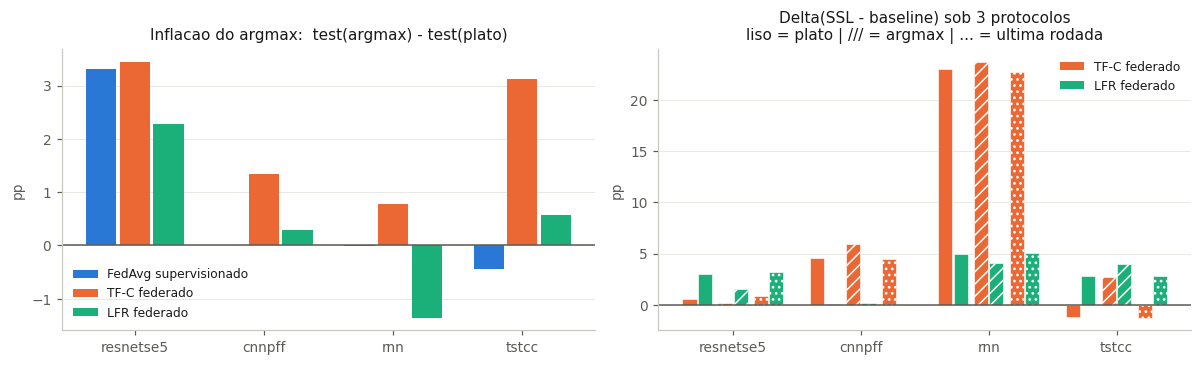

O tstcc/TF-C troca de sinal (+2,7 -> -1,2): e a celula com maior inflacao.


plateau      argmax       last     
              tfc  lfr    tfc  lfr   tfc  lfr
encoder                                      
resnetse5     0.6  3.0    0.2  1.5   0.9  3.2
cnnpff        4.6  0.1    6.0  0.2   4.5 -0.0
rnn          23.0  5.0   23.7  4.0  22.7  5.1
tstcc        -1.2  2.9    2.7  4.0  -1.2  2.9

In [3]:
def select(how='plateau', by_target=True):
    """Uma linha por run (e por alvo, se by_target). how in {plateau, argmax, last}."""
    g = KEY + (['target'] if by_target else [])
    if how == 'plateau':
        return raw[raw['round'] > RMAX - PLATEAU].groupby(g)['test_acc'].mean()
    if how == 'last':
        return raw[raw['round'] == RMAX].groupby(g)['test_acc'].mean()
    # argmax: a rodada e escolhida UMA vez por run (media da val sobre os alvos do
    # spec), porque o modelo e um so — nao se escolhe rodada diferente por alvo.
    v = raw.groupby(KEY + ['round'])['val_acc'].mean().reset_index()
    b = v.loc[v.groupby(KEY)['val_acc'].idxmax(), KEY + ['round']]
    return raw.merge(b, on=KEY + ['round']).groupby(g)['test_acc'].mean()

def delta_por_encoder(how):
    s = select(how, by_target=False).reset_index()
    p = s.pivot_table(index=['encoder', 'spec', 'n_shots', 'seed'],
                      columns='method', values='test_acc').dropna(subset=['none']) * 100
    return pd.DataFrame({m: (p[m] - p['none']).dropna().groupby(level='encoder').mean()
                         for m in SSL})

vies = ((select('argmax', by_target=False) - select('plateau', by_target=False)) * 100
        ).groupby(level=['method', 'encoder']).mean().unstack().reindex(columns=ENCODERS)
sens = {h: delta_por_encoder(h).reindex(ENCODERS) for h in ['plateau', 'argmax', 'last']}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
x, w = np.arange(len(ENCODERS)), 0.26
for k, m in enumerate(METHODS):
    style(ax1).bar(x + (k - 1) * w, vies.loc[m], w * 0.9, color=CM[m], label=LABEL[m])
ax1.axhline(0, color=INK2, lw=1)
ax1.set_xticks(x); ax1.set_xticklabels(ENCODERS)
ax1.set_ylabel('pp')
ax1.set_title('Inflacao do argmax:  test(argmax) - test(plato)', fontsize=10, color=INK)
ax1.legend(fontsize=8)

HATCH = {'plateau': '', 'argmax': '///', 'last': '...'}
for k, h in enumerate(['plateau', 'argmax', 'last']):
    for j, m in enumerate(SSL):
        style(ax2).bar(x + (k - 1) * 0.28 + (j - 0.5) * 0.12, sens[h][m], 0.11,
                       color=CM[m], hatch=HATCH[h], edgecolor='white', lw=0.4)
ax2.axhline(0, color=INK2, lw=1)
ax2.set_xticks(x); ax2.set_xticklabels(ENCODERS)
ax2.set_ylabel('pp')
ax2.set_title('Delta(SSL - baseline) sob 3 protocolos\n'
              'liso = plato | /// = argmax | ... = ultima rodada',
              fontsize=10, color=INK)
ax2.legend(handles=[Patch(facecolor=CM[m], label=LABEL[m]) for m in SSL], fontsize=8)
fig.tight_layout(); plt.show()

print('O tstcc/TF-C troca de sinal (+2,7 -> -1,2): e a celula com maior inflacao.')
display(pd.concat(sens, axis=1).round(1))

## 4. A ladder — resultado principal

Acurácia de teste por degrau de rótulos. Um painel por (braço × encoder): os braços são
condições experimentais distintas e **não devem ser mediados juntos**. Faixa = ±1 desvio
sobre as 4 seeds.

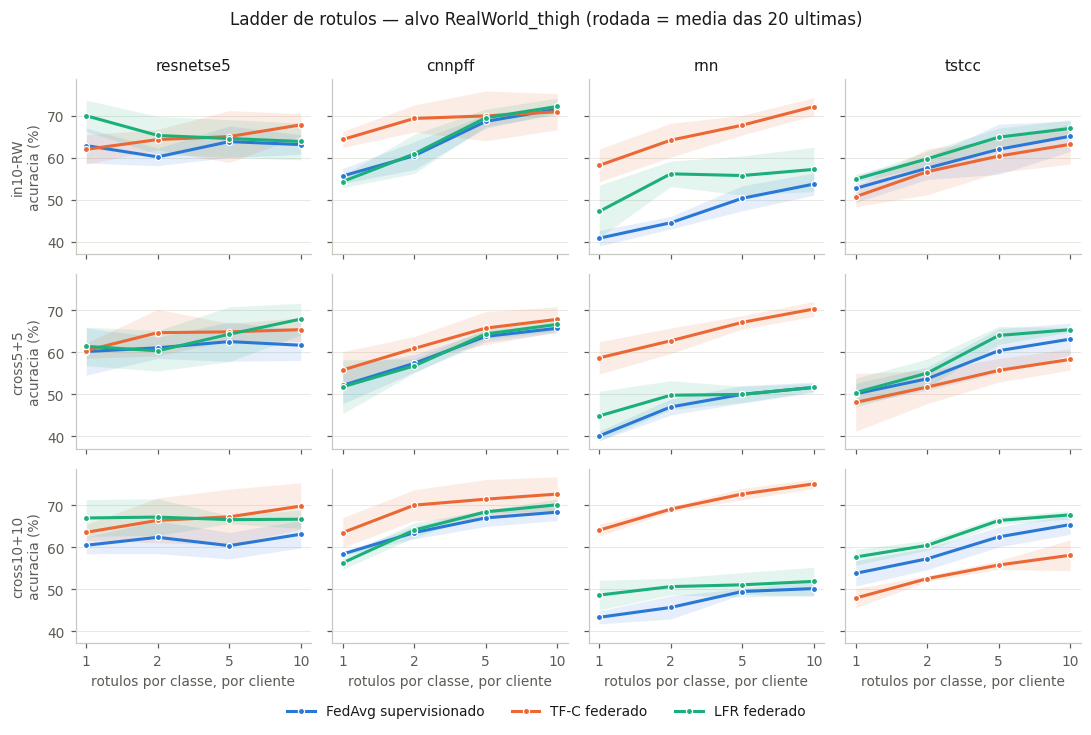

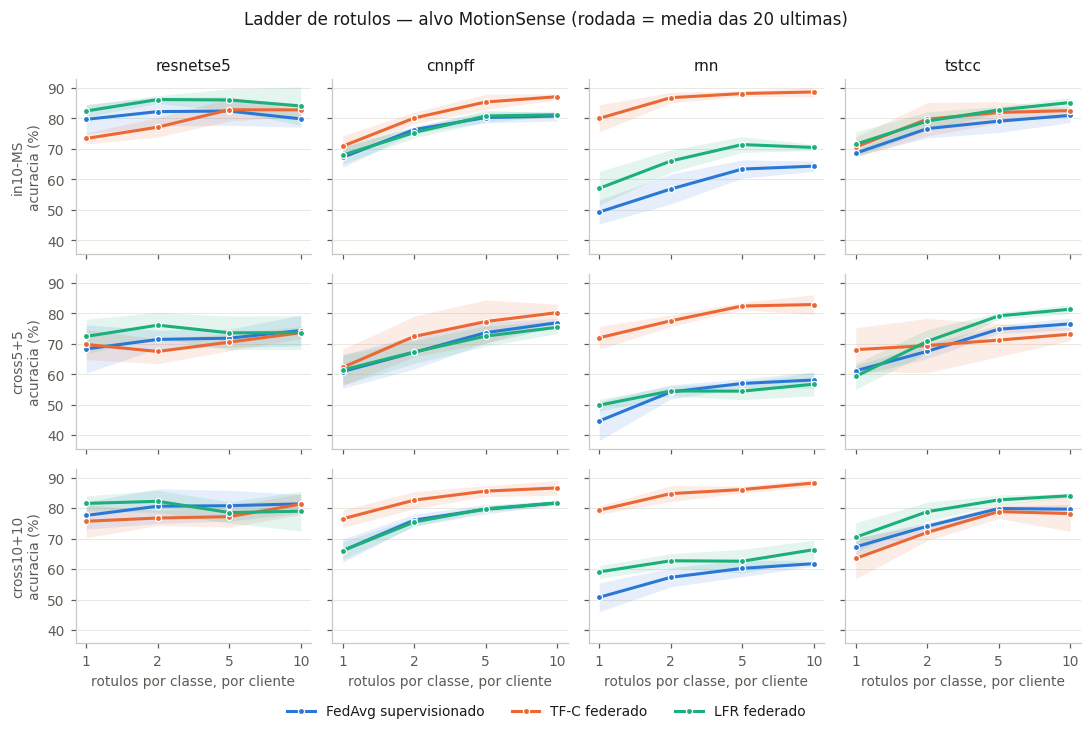

In [4]:
sel = select('plateau').reset_index()
sel['arm'] = sel['spec'].map(ARM)

def plot_ladder(target):
    d = sel[sel.target == target]
    arms = [a for a in ARM.values() if a in set(d.arm)]
    fig, axes = plt.subplots(len(arms), len(ENCODERS), sharex=True, sharey=True,
                             figsize=(2.5 * len(ENCODERS), 2.1 * len(arms)))
    axes = np.atleast_2d(axes)
    x = np.arange(len(SHOTS))
    for i, arm in enumerate(arms):
        for j, enc in enumerate(ENCODERS):
            ax = style(axes[i, j])
            for m in METHODS:                       # ordem FIXA: cor segue o metodo
                s = d[(d.arm == arm) & (d.encoder == enc) & (d.method == m)]
                g = (s.groupby('n_shots')['test_acc'].agg(['mean', 'std']) * 100
                     ).reindex(SHOTS)
                if g['mean'].isna().all():
                    continue
                ax.plot(x, g['mean'], color=CM[m], lw=2, marker='o', ms=4,
                        mec='white', mew=0.8, label=LABEL[m], zorder=3)
                ax.fill_between(x, g['mean'] - g['std'], g['mean'] + g['std'],
                                color=CM[m], alpha=0.12, lw=0, zorder=2)
            if i == 0:
                ax.set_title(enc, fontsize=10, color=INK)
            if j == 0:
                ax.set_ylabel(f'{arm}\nacuracia (%)', fontsize=9)
            ax.set_xticks(x); ax.set_xticklabels(SHOTS)
    for ax in axes[-1]:
        ax.set_xlabel('rotulos por classe, por cliente')
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(f'Ladder de rotulos — alvo {target} '
                 f'(rodada = media das {PLATEAU} ultimas)', y=1.0, fontsize=11)
    fig.tight_layout(); plt.show()

for tgt in IN_SPEC:
    plot_ladder(tgt)

### 4.1 O ganho do SSL some quando chegam rótulos?

A previsão clássica da literatura de SSL é que sim. O degrau `full` do baseline não está
nesta grade (`run_grid_fedssl.py` só roda `method=none` em 1/2/5/10) — vem de
`fed_cross_device.csv` e é juntado aqui para fechar a curva.

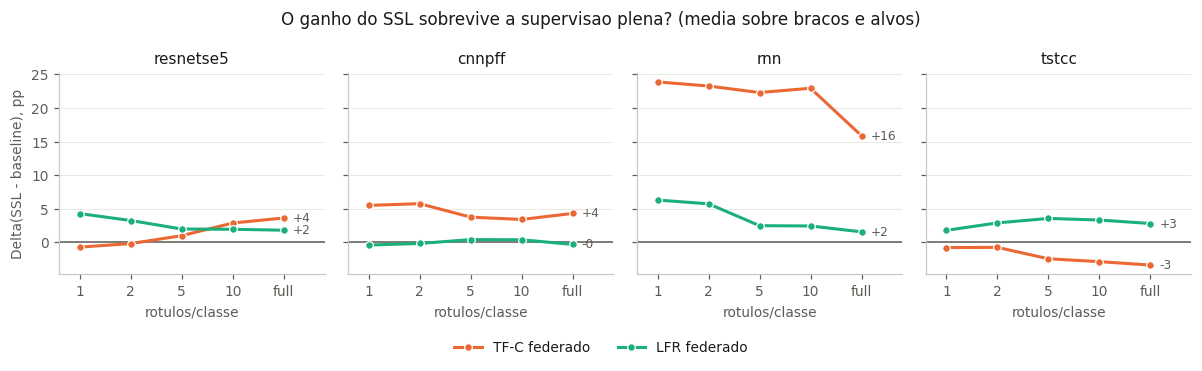

tfc                          lfr                    
              1    10     2     5  full    1   10    2    5 full
cnnpff      5.5   3.4   5.8   3.7   4.3 -0.4  0.4 -0.2  0.4 -0.3
resnetse5  -0.7   2.9  -0.2   1.0   3.6  4.3  1.9  3.2  2.0  1.8
rnn        23.9  22.9  23.3  22.3  15.9  6.3  2.4  5.7  2.5  1.6
tstcc      -0.8  -2.9  -0.8  -2.5  -3.4  1.8  3.3  2.9  3.6  2.8

In [5]:
b = pd.read_csv(BASE_CSV)
b = b[(b['local_epochs'] == 5) & (b['round'] > b['round'].max() - PLATEAU)
      & b.spec.isin(ARM)]
base_full = b.groupby(['encoder', 'spec', 'target'])['test_acc'].mean() * 100
ssl_full = (sel[sel.n_shots == 'full']
            .groupby(['encoder', 'spec', 'target', 'method'])['test_acc'].mean() * 100)

p_low = (sel[sel.n_shots.isin(SHOTS)]
         .pivot_table(index=['encoder', 'spec', 'target', 'n_shots', 'seed'],
                      columns='method', values='test_acc') * 100)
curva_full = {}
for m in SSL:
    low = (p_low[m] - p_low['none']).dropna().groupby(level=['encoder', 'n_shots']).mean()
    hi = (ssl_full.xs(m, level='method') - base_full).dropna().groupby('encoder').mean()
    curva_full[m] = {**{(e, s): low.get((e, s), np.nan) for e in ENCODERS for s in SHOTS},
                     **{(e, 'full'): hi.get(e, np.nan) for e in ENCODERS}}

fig, axes = plt.subplots(1, len(ENCODERS), figsize=(11, 3.0), sharey=True)
x = np.arange(len(ALL_SHOTS))
for ax, enc in zip(axes, ENCODERS):
    style(ax)
    for m in SSL:
        y = [curva_full[m][(enc, s)] for s in ALL_SHOTS]
        ax.plot(x, y, color=CM[m], lw=2, marker='o', ms=5, mec='white', mew=0.8,
                label=LABEL[m], zorder=3)
        ax.annotate(f'{y[-1]:+.0f}', (x[-1], y[-1]), textcoords='offset points',
                    xytext=(6, 0), fontsize=8, color=INK2, va='center')
    ax.axhline(0, color=INK2, lw=1, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(ALL_SHOTS)
    ax.set_xlim(-0.4, len(ALL_SHOTS) - 0.2)
    ax.set_title(enc, fontsize=10, color=INK)
    ax.set_xlabel('rotulos/classe')
axes[0].set_ylabel('Delta(SSL - baseline), pp')
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.10))
fig.suptitle('O ganho do SSL sobrevive a supervisao plena? '
             '(media sobre bracos e alvos)', fontsize=11)
fig.tight_layout(); plt.show()
display(pd.DataFrame(curva_full).unstack().round(1))

### 4.2 O ganho por braço — a 4.1 mistura os três

A figura da 4.1 média **todos os specs juntos**: `in10`, `cross5+5` e `cross10+10`
entram na mesma curva. Isso responde "o SSL ajuda?" mas não "ajuda **onde**?" — e os
três braços são condições experimentais diferentes, não repetições.

Aqui o mesmo Δ(SSL − SL) aparece separado por braço:

| braço | clientes |
|---|---|
| `in10` | 10 do próprio domínio (média dos dois alvos: `in10-RW` e `in10-MS`) |
| `cross5+5` | 5 próprios + 5 estrangeiros — mesmo total, metade do dado próprio sai |
| `cross10+10` | 10 próprios **intactos** + 10 estrangeiros por cima |

**O degrau `full` entra aqui, e ele muda de fonte.** A grade Fed-SSL não tem braço
`none` no `full` (o baseline supervisionado já mediu o shard inteiro em
`fed_cross_device.csv`). A junção é legítima — mesmo protocolo: R=150, budget 192,
`local_epochs=5`, seeds 0–3 — mas é **outro mutirão**, e por isso a linha pontilhada
marca a fronteira em toda figura que usa o `full`. A 4.1 já fazia essa junção
mediando as seeds; aqui ela é pareada por seed, para o `full` entrar nas contas de
ruído do §9 em pé de igualdade com os demais degraus.

A escala do eixo y é compartilhada **por linha** (braço), não pela figura toda: é o
que permite comparar encoders dentro de um braço sem que o `rnn` achate os demais.

[full] 96 de 96 celulas do baseline juntadas de fed_cross_device.csv


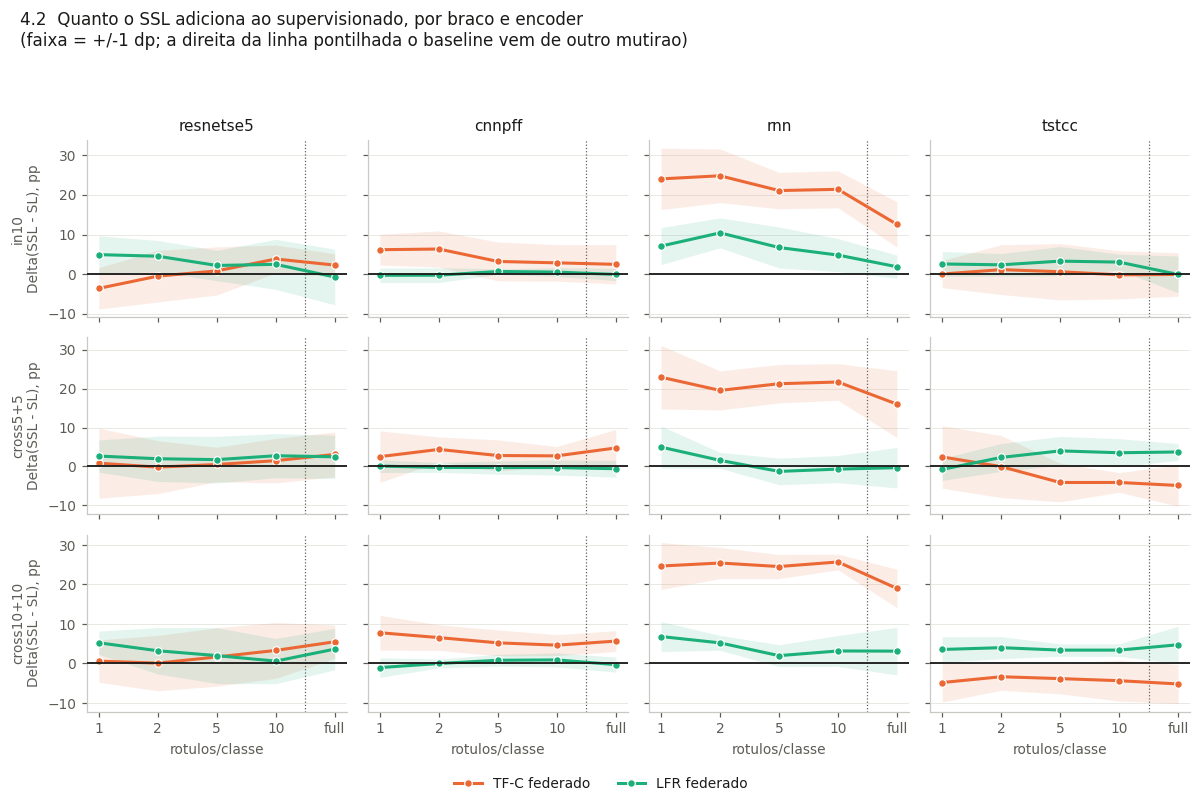

Delta(SSL - SL) medio por braco, encoder e metodo (pp):
metodo                 tfc                          lfr                     
n_shots                  1     2     5    10  full    1     2    5   10 full
braco      encoder                                                          
in10       resnetse5  -3.6  -0.5   0.8   3.8   2.3  4.9   4.5  2.2  2.5 -0.7
           cnnpff      6.2   6.3   3.2   2.9   2.5 -0.3  -0.3  0.7  0.5 -0.1
           rnn        24.0  24.8  21.1  21.4  12.6  7.1  10.4  6.7  4.8  1.9
           tstcc       0.0   1.1   0.6  -0.2  -0.1  2.6   2.4  3.3  3.0 -0.1
cross5+5   resnetse5   0.8  -0.2   0.5   1.5   3.1  2.7   2.0  1.8  2.8  2.5
           cnnpff      2.5   4.4   2.8   2.7   4.8  0.1  -0.2 -0.3 -0.3 -0.6
           rnn        22.9  19.5  21.3  21.7  16.0  5.0   1.6 -1.3 -0.7 -0.3
           tstcc       2.4  -0.0  -4.1  -4.1  -4.9 -0.8   2.3  4.0  3.5  3.7
cross10+10 resnetse5   0.6   0.1   1.6   3.3   5.5  5.2   3.2  2.0  0.6  3.6
           cnnpff   

In [6]:
BRACO = {'in10-RW': 'in10', 'in10-MS': 'in10',
         'cross5+5': 'cross5+5', 'cross10+10': 'cross10+10'}
BRACOS = ['in10', 'cross5+5', 'cross10+10']
TIT_BRACO = {'in10': 'in10 — 10 clientes do proprio dominio',
             'cross5+5': 'cross5+5 — metade dos clientes e estrangeira',
             'cross10+10': 'cross10+10 — dominio proprio intacto, +10 estrangeiros'}

def base_full_seed():
    """Baseline supervisionado no degrau `full`, PAREADO POR SEED.

    A grade Fed-SSL nao tem braco `none` no `full` (o baseline ja media o shard
    inteiro), entao ele vem de fed_cross_device.csv. Mesmo protocolo — R=150,
    budget 192, local_epochs=5, seeds 0-3 —, mas OUTRO mutirao: e a ressalva 6 do
    notebook de barras, e vale para toda leitura do degrau `full`.

    A §4.1 faz a mesma juncao mediando as seeds; aqui o pareamento por seed e
    preservado, para o `full` entrar nas contas de ruido do §9 em pe de igualdade
    com os demais degraus."""
    b = pd.read_csv(BASE_CSV)
    b = b[(b.local_epochs == 5) & (b['round'] > b['round'].max() - PLATEAU)
          & b.spec.isin(ARM)]
    return b.groupby(['encoder', 'spec', 'target', 'seed'])['test_acc'].mean() * 100

def delta_ssl_sl():
    """Delta(SSL - supervisionado) por (encoder, metodo, spec, alvo, degrau, seed).

    Fonte unica das figuras que comparam SSL com o baseline: degraus 1/2/5/10 saem
    inteiros da grade Fed-SSL; no `full` o lado supervisionado vem do baseline."""
    q = (sel.pivot_table(index=['encoder', 'spec', 'target', 'n_shots', 'seed'],
                         columns='method', values='test_acc') * 100)
    sl = q['none'].copy()
    bf = base_full_seed()
    falta = sl.index[sl.isna() & (sl.index.get_level_values('n_shots') == 'full')]
    achou = [i for i in falta if (i[0], i[1], i[2], i[4]) in bf.index]
    sl.loc[achou] = [bf.loc[(i[0], i[1], i[2], i[4])] for i in achou]
    print(f'[full] {len(achou)} de {len(falta)} celulas do baseline juntadas '
          f'de {BASE_CSV.name}')
    r = pd.concat([(q[m] - sl).dropna().rename('delta').reset_index().assign(metodo=m)
                   for m in SSL], ignore_index=True)
    r['arm'] = r.spec.map(ARM)
    r['braco'] = r.arm.map(BRACO)
    return r

dssl = delta_ssl_sl()

def plot_ganho_por_braco(r):
    fig, axes = plt.subplots(len(BRACOS), len(ENCODERS), sharex=True, sharey='row',
                             figsize=(11, 7.2))
    x = np.arange(len(ALL_SHOTS))
    for i, br in enumerate(BRACOS):
        for j, enc in enumerate(ENCODERS):
            ax = style(axes[i, j])
            for m in SSL:                       # ordem FIXA: cor segue o metodo
                s = r[(r.braco == br) & (r.encoder == enc) & (r.metodo == m)]
                g = s.groupby('n_shots')['delta'].agg(['mean', 'std']).reindex(ALL_SHOTS)
                ax.plot(x, g['mean'], color=CM[m], lw=2, marker='o', ms=5,
                        mec='white', mew=0.8, label=LABEL[m], zorder=3)
                ax.fill_between(x, g['mean'] - g['std'], g['mean'] + g['std'],
                                color=CM[m], alpha=0.12, lw=0, zorder=2)
            ax.axhline(0, color=INK, lw=1.2, zorder=4)
            ax.axvline(len(SHOTS) - 0.5, color=INK2, lw=0.8, ls=':', zorder=1)
            ax.set_xticks(x); ax.set_xticklabels(ALL_SHOTS)
            if i == 0:
                ax.set_title(enc, fontsize=10, color=INK)
            if j == 0:
                ax.set_ylabel(f'{br}\nDelta(SSL - SL), pp', fontsize=9)
            if i == len(BRACOS) - 1:
                ax.set_xlabel('rotulos/classe')
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle('4.2  Quanto o SSL adiciona ao supervisionado, por braco e encoder\n'
                 '(faixa = +/-1 dp; a direita da linha pontilhada o baseline vem de outro mutirao)',
                 fontsize=11, x=0.02, ha='left')
    fig.tight_layout(rect=[0, 0.02, 1, 0.93])
    plt.show()

plot_ganho_por_braco(dssl)
print('Delta(SSL - SL) medio por braco, encoder e metodo (pp):')
print(dssl.pivot_table(index=['braco', 'encoder'], columns=['metodo', 'n_shots'],
                       values='delta')
      .reindex([(b, e) for b in BRACOS for e in ENCODERS])
      .reindex(columns=[(m, s) for m in SSL for s in ALL_SHOTS]).round(1).to_string())


## 5. Domain shift: o Δ A e a diferença-em-diferenças

Com o alvo fixo:

```
A   = acc(cross5+5, SSL) - acc(cross5+5, SL)     # o SSL ajuda no cenario cross-domain?
B   = acc(in-domain, SSL) - acc(in-domain, SL)   # ...e no cenario in-domain?
DiD = A - B                                       # o SSL ataca o SHIFT especificamente?
```

**As duas são úteis e respondem coisas diferentes.**

- **A é o número de *deployment*:** *"vou operar uma federação cross-domain — o SSL
  ajuda?"* É o que interessa a um leitor aplicado, e não precisa de controle nenhum.
- **DiD é o número *mecanístico*:** *"o SSL ataca especificamente a heterogeneidade de
  domínio?"* É o que a motivação original do projeto afirma.

**A sozinho não mede mitigação.** Se o SSL for uniformemente melhor, A é grande sem que
o custo do shift mude — é o caso do `rnn`, onde A é enorme mas B é ainda maior: o SSL
está consertando o *encoder*, não o *shift*.

O gráfico de halteres mostra os dois de uma vez: cada linha liga B a A, e **o comprimento
da linha é o DiD**. Linha curta = o SSL ajuda igual nos dois cenários.

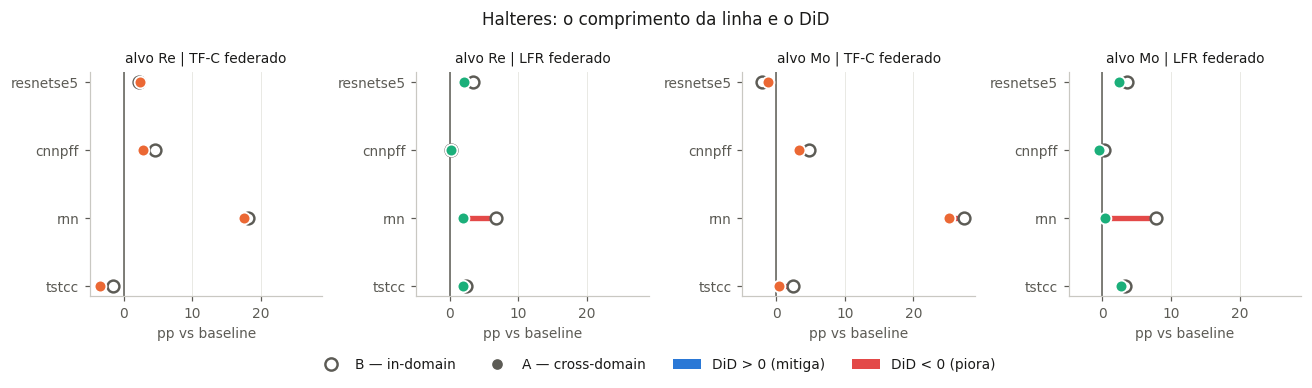

In [7]:
p = sel.pivot_table(index=['encoder', 'n_shots', 'seed', 'target'],
                    columns=['method', 'spec'], values='test_acc') * 100

def abd(target, method, level=('encoder',)):
    """A, B e DiD pareados por seed (media e dp)."""
    d = p.xs(target, level='target')
    A = (d[(method, C55)] - d[('none', C55)]).dropna()
    B = (d[(method, IN_SPEC[target])] - d[('none', IN_SPEC[target])]).dropna()
    i = A.index.intersection(B.index)
    out = pd.DataFrame({'A': A.loc[i], 'B': B.loc[i], 'DiD': A.loc[i] - B.loc[i]})
    g = out.groupby(level=list(level))
    return pd.concat({'media': g.mean(), 'dp': g.std()}, axis=1)

fig, axes = plt.subplots(1, 4, sharex=True, figsize=(12, 3.2))
for ax, (tgt, m) in zip(axes, [(t, m) for t in IN_SPEC for m in SSL]):
    d = abd(tgt, m).reindex(ENCODERS)
    y = np.arange(len(ENCODERS))
    style(ax, 'x')
    for k, enc in enumerate(ENCODERS):
        a, bb = d.loc[enc, ('media', 'A')], d.loc[enc, ('media', 'B')]
        ax.plot([bb, a], [k, k], color=POS if a > bb else NEG, lw=3.5, zorder=3,
                solid_capstyle='round')
    ax.scatter(d[('media', 'B')], y, s=60, color='white', ec=INK2, lw=1.6, zorder=4)
    ax.scatter(d[('media', 'A')], y, s=60, color=CM[m], ec='white', lw=1.2, zorder=5)
    ax.axvline(0, color=INK2, lw=1, zorder=2)
    ax.set_yticks(y); ax.set_yticklabels(ENCODERS)
    ax.invert_yaxis()          # mesma ordem de leitura das outras figuras
    ax.set_title(f'alvo {tgt[:2]} | {LABEL[m]}', fontsize=9, color=INK)
    ax.set_xlabel('pp vs baseline')
fig.legend(handles=[
    plt.Line2D([], [], marker='o', ls='', mfc='white', mec=INK2, mew=1.6, ms=8,
               label='B — in-domain'),
    plt.Line2D([], [], marker='o', ls='', mfc=INK2, mec='white', ms=8,
               label='A — cross-domain'),
    Patch(facecolor=POS, label='DiD > 0 (mitiga)'),
    Patch(facecolor=NEG, label='DiD < 0 (piora)')],
    loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('Halteres: o comprimento da linha e o DiD', fontsize=11)
fig.tight_layout(); plt.show()

### 5.1 O Δ A por regime de rótulos

Quanto o SSL entrega **dentro do cenário cross-domain**, degrau a degrau. É a leitura de
deployment: nenhum controle subtraído, o número que o operador do sistema veria.

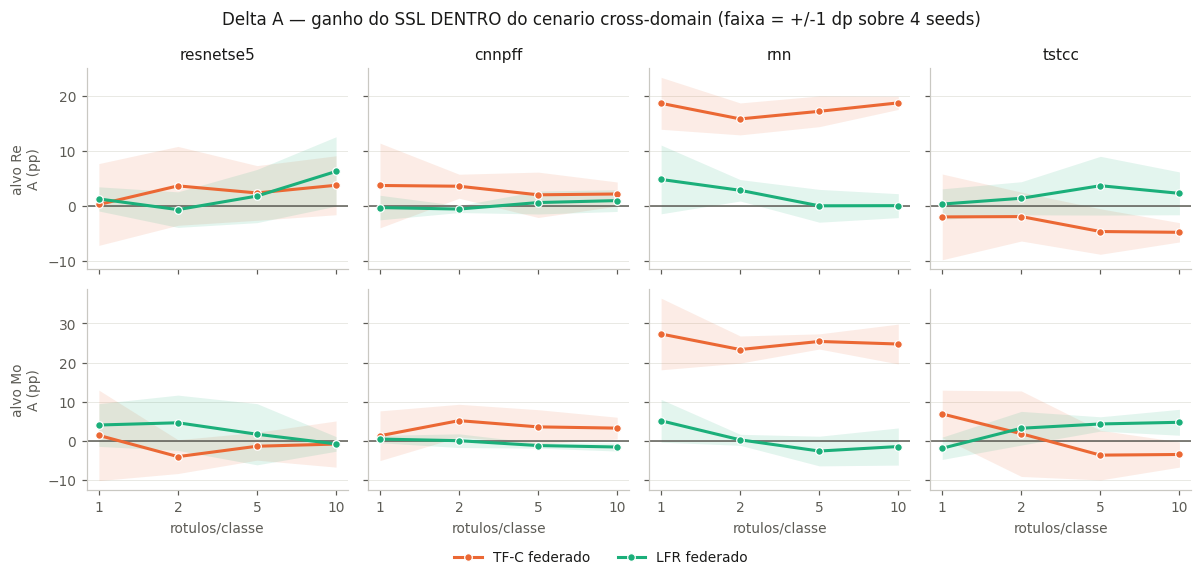

In [8]:
def curva(campo, titulo):
    fig, axes = plt.subplots(2, len(ENCODERS), sharex=True, sharey='row',
                             figsize=(11, 5.0))
    x = np.arange(len(SHOTS))
    for i, tgt in enumerate(IN_SPEC):
        for j, enc in enumerate(ENCODERS):
            ax = style(axes[i, j])
            for m in SSL:
                d = abd(tgt, m, level=('encoder', 'n_shots'))
                mu = np.array([d.loc[(enc, s), ('media', campo)]
                               if (enc, s) in d.index else np.nan for s in SHOTS], float)
                sd = np.array([d.loc[(enc, s), ('dp', campo)]
                               if (enc, s) in d.index else np.nan for s in SHOTS], float)
                ax.plot(x, mu, color=CM[m], lw=2, marker='o', ms=5, mec='white',
                        mew=0.8, label=LABEL[m], zorder=3)
                ax.fill_between(x, mu - sd, mu + sd, color=CM[m], alpha=0.12,
                                lw=0, zorder=2)
            ax.axhline(0, color=INK2, lw=1, zorder=2)
            ax.set_xticks(x); ax.set_xticklabels(SHOTS)
            if i == 0:
                ax.set_title(enc, fontsize=10, color=INK)
            if j == 0:
                ax.set_ylabel(f'alvo {tgt[:2]}\n{campo} (pp)')
            if i == 1:
                ax.set_xlabel('rotulos/classe')
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle(titulo, fontsize=11)
    fig.tight_layout(); plt.show()

curva('A', 'Delta A — ganho do SSL DENTRO do cenario cross-domain '
           '(faixa = +/-1 dp sobre 4 seeds)')

### 5.2 O DiD por regime de rótulos

Mesma leitura, agora com o controle in-domain subtraído. Se o SSL mitigasse shift, seria
de esperar que mitigasse **mais** onde há menos rótulos para compensar.

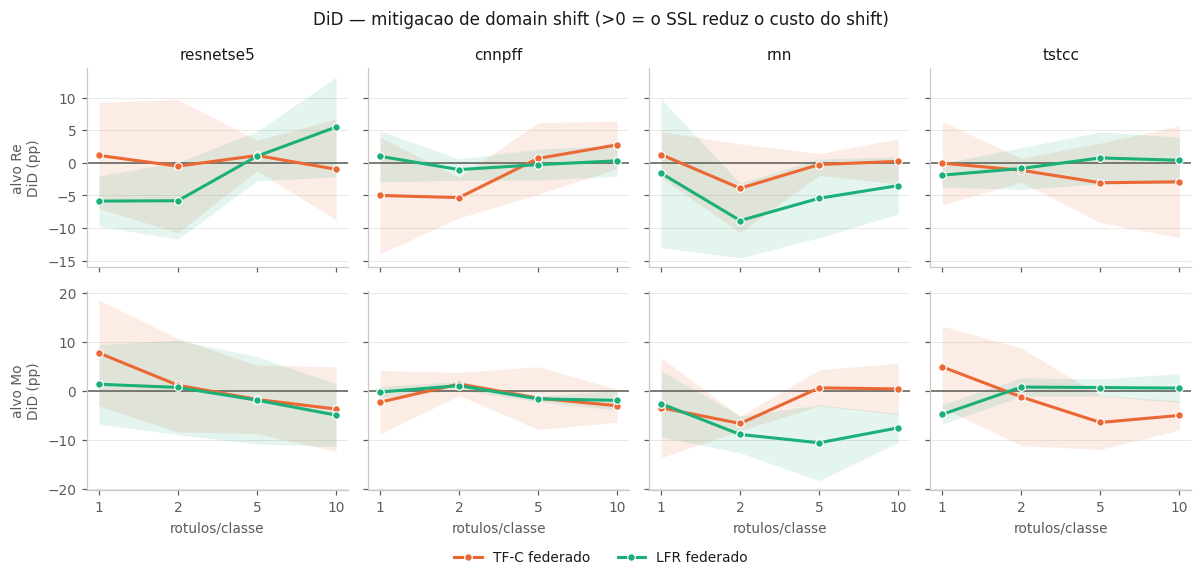

A e DiD por celula (pp) — EXPLORATORIO, ver §7


Re                   Mo                
                    tfc       lfr        tfc       lfr      
                      A  DiD    A  DiD     A  DiD    A   DiD
encoder   n_shots                                           
resnetse5 1         0.2  1.1  1.2 -5.9   1.5  7.7  4.1   1.4
          2         3.6 -0.5 -0.7 -5.8  -4.0  1.2  4.7   0.7
          5         2.3  1.1  1.8  1.0  -1.3 -1.7  1.8  -1.9
          10        3.7 -1.0  6.2  5.5  -0.7 -3.7 -0.7  -4.9
cnnpff    1         3.7 -5.0 -0.3  1.0   1.4 -2.3  0.5  -0.2
          2         3.5 -5.3 -0.6 -1.0   5.2  1.4  0.1   1.1
          5         2.0  0.7  0.6 -0.3   3.6 -1.5 -1.1  -1.6
          10        2.1  2.7  0.9  0.3   3.3 -3.0 -1.5  -1.9
rnn       1        18.6  1.3  4.8 -1.6  27.3 -3.4  5.2  -2.6
          2        15.8 -3.9  2.8 -8.9  23.3 -6.6  0.3  -8.9
          5        17.1 -0.3 -0.0 -5.4  25.4  0.6 -2.5 -10.6
          10       18.7  0.2  0.0 -3.5  24.7  0.4 -1.4  -7.5
tstcc     1        -2.0 -0.1  0.3 -1.9   6.9  4.9 -1.8  -4.8
          2        -2.0 -1.1  1.4 -0.9   1.9 -1.2  3.3   0.8
          5        -4.7 -3.1  3.6  0.7  -3.6 -6.4  4.4   0.7
          10       -4.8 -2.9  2.2  0.4  -3.4 -5.0  4.8   0.6

In [9]:
curva('DiD', 'DiD — mitigacao de domain shift (>0 = o SSL reduz o custo do shift)')

tab = {}
for tgt in IN_SPEC:
    for m in SSL:
        d = abd(tgt, m, level=('encoder', 'n_shots'))['media']
        for c in ['A', 'DiD']:
            tab[(tgt[:2], m, c)] = d[c]
tab = pd.DataFrame(tab)
print('A e DiD por celula (pp) — EXPLORATORIO, ver §7')
display(tab.reindex([(e, s) for e in ENCODERS for s in SHOTS]).round(1))

## 6. Teste independente: mitigação aparece onde há shift?

A hipótese que o §5 sugere é *"o SSL mitiga onde há o que mitigar"*.

**Não se pode testar isso correlacionando DiD contra o custo de shift medido no próprio
baseline.** `DiD = shift_SSL − shift_SL`, então `shift_SL` entra nos dois eixos com
sinais opostos: ruído puro já produz correlação negativa (regressão à média). Feito
assim dá r = −0,70, e isso não significa nada.

O teste limpo usa um gap medido em **runs independentes**: a matriz de transfer
supervisionada centralizada, que não compartilha nenhuma execução com esta grade.

```
gap(encoder, alvo) = acc(fonte = alvo -> alvo) - acc(fonte = o outro dominio -> alvo)
```

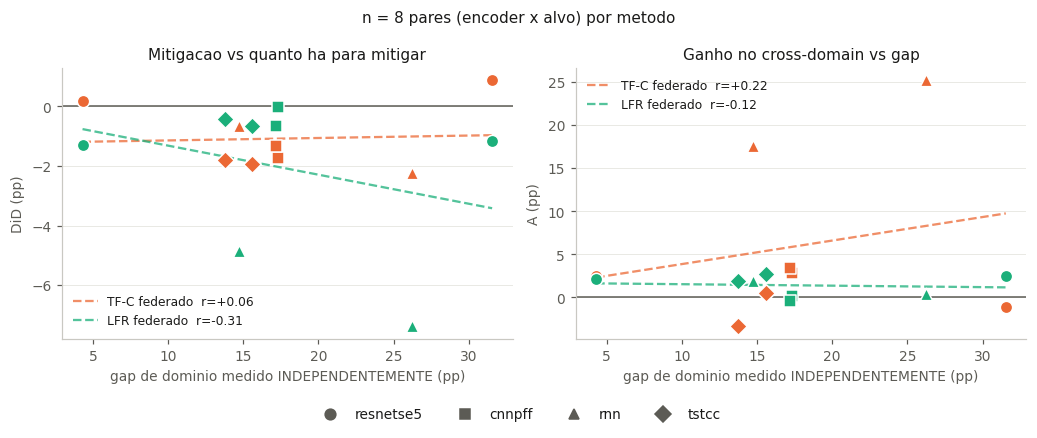

ATENCAO: com 8 pontos o intervalo de confianca de r e larguissimo — estes
numeros servem para NAO afirmar, nao para afirmar.


A        DiD        gap      
metodo          lfr   tfc  lfr  tfc   lfr   tfc
alvo encoder                                   
Mo   cnnpff    -0.5   3.4 -0.7 -1.3  17.2  17.2
     resnetse5  2.5  -1.1 -1.2  0.9  31.5  31.5
     rnn        0.4  25.2 -7.4 -2.3  26.2  26.2
     tstcc      2.7   0.5 -0.7 -1.9  15.6  15.6
Re   cnnpff     0.1   2.8 -0.0 -1.7  17.3  17.3
     resnetse5  2.1   2.5 -1.3  0.2   4.3   4.3
     rnn        1.9  17.5 -4.8 -0.7  14.7  14.7
     tstcc      1.9  -3.4 -0.4 -1.8  13.8  13.8

In [10]:
slt = pd.read_csv(SL_TRANSFER)
slt = slt[slt.n_shots.astype(str) == 'full']
par = list(IN_SPEC)
mat = (slt[slt.source.isin(par) & slt.target.isin(par)]
       .groupby(['encoder', 'source', 'target'])['test_acc'].mean() * 100)

reg = []
for tgt in par:
    outro = [d for d in par if d != tgt][0]
    for enc in ENCODERS:
        gap = mat.loc[(enc, tgt, tgt)] - mat.loc[(enc, outro, tgt)]
        for m in SSL:
            d = abd(tgt, m).reindex(ENCODERS)
            reg.append(dict(alvo=tgt[:2], encoder=enc, metodo=m, gap=gap,
                            A=d.loc[enc, ('media', 'A')],
                            DiD=d.loc[enc, ('media', 'DiD')]))
reg = pd.DataFrame(reg)

MK = {'resnetse5': 'o', 'cnnpff': 's', 'rnn': '^', 'tstcc': 'D'}
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharex=True)
for ax, campo in zip(axes, ['DiD', 'A']):
    style(ax)
    for m in SSL:
        s = reg[reg.metodo == m]
        for _, row in s.iterrows():
            ax.scatter(row.gap, row[campo], s=65, color=CM[m], marker=MK[row.encoder],
                       ec='white', lw=1, zorder=3)
        r = np.corrcoef(s.gap, s[campo])[0, 1]
        xs = np.linspace(reg.gap.min(), reg.gap.max(), 10)
        ax.plot(xs, np.polyval(np.polyfit(s.gap, s[campo], 1), xs), color=CM[m],
                lw=1.5, ls='--', alpha=0.75, label=f'{LABEL[m]}  r={r:+.2f}', zorder=2)
    ax.axhline(0, color=INK2, lw=1, zorder=1)
    ax.set_xlabel('gap de dominio medido INDEPENDENTEMENTE (pp)')
    ax.set_ylabel(f'{campo} (pp)')
    ax.legend(fontsize=8)
axes[0].set_title('Mitigacao vs quanto ha para mitigar', fontsize=10, color=INK)
axes[1].set_title('Ganho no cross-domain vs gap', fontsize=10, color=INK)
fig.legend(handles=[plt.Line2D([], [], marker=MK[e], ls='', color=INK2, ms=7, label=e)
                    for e in ENCODERS],
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.09))
fig.suptitle('n = 8 pares (encoder x alvo) por metodo', fontsize=10)
fig.tight_layout(); plt.show()

print('ATENCAO: com 8 pontos o intervalo de confianca de r e larguissimo — estes\n'
      'numeros servem para NAO afirmar, nao para afirmar.')
display(reg.pivot_table(index=['alvo', 'encoder'], columns='metodo',
                        values=['gap', 'A', 'DiD']).round(1))

## 7. O backbone precisa ter sido pré-treinado no domínio do alvo?

Até aqui, pré-treino e fine-tuning sempre usaram **a mesma gente**: o backbone do
`in10-RW` foi pré-treinado nos 10 usuários do RealWorld_thigh e ajustado nesses mesmos
10. Isso deixa uma pergunta sem resposta — o ganho vem de a representação ser *boa*, ou
de ela ter sido feita sob medida para aquelas pessoas?

A grade `--pretrain-spec` separa as duas coisas. O fine-tuning continua **idêntico** (os
mesmos 10 usuários do alvo, os mesmos rótulos, as mesmas 150 rodadas); só o backbone de
partida muda de origem:

| braço | pré-treino | fine-tuning |
|---|---|---|
| `none` | nenhum (pesos aleatórios) | 10 usuários do alvo |
| **in-domain** | 10 usuários **do alvo** | 10 usuários do alvo |
| **cross-domain** | 10 usuários **do outro dataset** | 10 usuários do alvo |

Se as duas curvas coincidirem, a representação é geral: dá para pré-treinar em quem
estiver disponível. Se a `cross` desabar até o `none`, o pré-treino só serve para a
população em que foi feito — o que seria uma limitação séria num sistema real, onde
quem fornece dado não-rotulado raramente é quem vai usar o modelo.

cross-dominio: 48,000 linhas | Exp.2 (single): 48,000 linhas


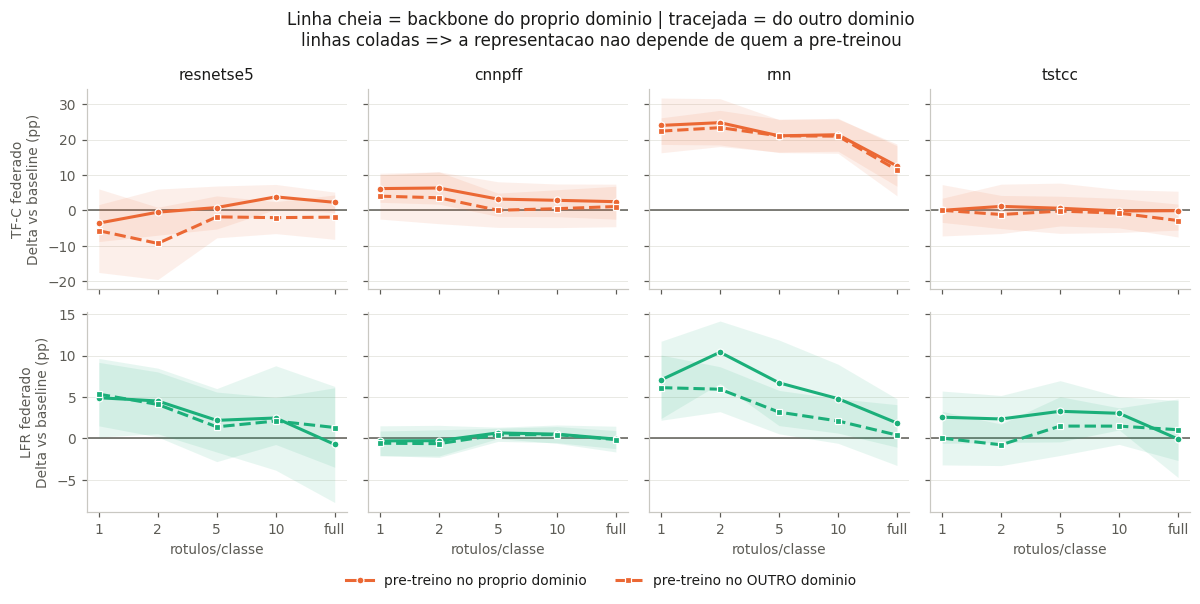

proprio  outro  custo_transf
method encoder                                
tfc    resnetse5      0.6   -4.2          -4.7
       cnnpff         4.2    1.8          -2.4
       rnn           20.8   19.9          -0.9
       tstcc          0.3   -1.0          -1.3
lfr    resnetse5      2.7    2.9           0.2
       cnnpff         0.1   -0.1          -0.2
       rnn            6.2    3.6          -2.6
       tstcc          2.2    0.7          -1.6

In [11]:
XPART_DIR = PROJECT_ROOT / 'results' / 'fedssl_crossspec_parts'
SIMPLE = list(IN_SPEC.values())          # so os dois bracos in-domain tem par cruzado

# Um subdiretorio por POPULACAO DE PRE-TREINO: `pre-device-*` = §7 (backbone feito
# no outro dominio), `pre-single-*` = §8 (backbone feito num cliente so). Sao
# perguntas diferentes e nao entram na mesma media — por isso a separacao esta na
# ARVORE DE DIRETORIOS, visivel no `ls`, e nao apenas numa coluna do CSV.
def ler(padrao):
    fs = sorted(XPART_DIR.glob(f'{padrao}/*.csv'))
    if not fs:
        return pd.DataFrame(columns=['n_shots', 'round', 'test_acc'])
    d = pd.concat([pd.read_csv(f) for f in fs], ignore_index=True)
    d['n_shots'] = d['n_shots'].astype(str)
    return d

xdev = ler('pre-device-*')       # §7 — transfer de dominio
xsingle = ler('pre-single-*')    # §8 — Exp. 2
print(f'cross-dominio: {len(xdev):,} linhas | Exp.2 (single): {len(xsingle):,} linhas')

def plato(df, extra=()):
    """Media das PLATEAU ultimas rodadas — mesma regra do §3."""
    g = KEY + ['target'] + list(extra)
    return df[df['round'] > RMAX - PLATEAU].groupby(g)['test_acc'].mean() * 100

# Piso `none`: 1/2/5/10 vem desta grade; `full` vem do baseline congelado.
bfull = pd.read_csv(BASE_CSV)
bfull = bfull[(bfull['local_epochs'] == 5) & bfull.spec.isin(SIMPLE)
              & (bfull['round'] > bfull['round'].max() - PLATEAU)].copy()
bfull['n_shots'], bfull['method'] = 'full', 'none'
piso = pd.concat([plato(raw[raw.method == 'none']).reset_index(),
                  plato(bfull).reset_index()], ignore_index=True)
piso = (piso.drop(columns='method')
            .rename(columns={'test_acc': 'none'})
            .set_index(['encoder', 'spec', 'seed', 'n_shots', 'target']))

def contra_piso(s):
    """Δ vs `none`, pareado na MESMA seed/spec/alvo/degrau — nunca media contra media."""
    d = s.reset_index().join(piso, on=piso.index.names)
    return d.dropna(subset=['none']).assign(delta=lambda x: x.test_acc - x['none'])

d_in = contra_piso(plato(raw[raw.method.isin(SSL) & raw.spec.isin(SIMPLE)]))
d_cross = contra_piso(plato(xdev))

fig, axes = plt.subplots(len(SSL), len(ENCODERS), sharex=True, sharey='row',
                         figsize=(11, 5.2))
x = np.arange(len(ALL_SHOTS))
for i, m in enumerate(SSL):
    for j, enc in enumerate(ENCODERS):
        ax = style(axes[i, j])
        for d, ls, mk, lab in ((d_in, '-', 'o', 'pre-treino no proprio dominio'),
                               (d_cross, '--', 's', 'pre-treino no OUTRO dominio')):
            s = d[(d.method == m) & (d.encoder == enc)]
            g = s.groupby('n_shots')['delta'].agg(['mean', 'std']).reindex(ALL_SHOTS)
            ax.plot(x, g['mean'], color=CM[m], lw=2, ls=ls, marker=mk, ms=4.5,
                    mec='white', mew=0.8, label=lab, zorder=3)
            ax.fill_between(x, g['mean'] - g['std'], g['mean'] + g['std'],
                            color=CM[m], alpha=0.10, lw=0, zorder=2)
        ax.axhline(0, color=INK2, lw=1, zorder=1)
        ax.set_xticks(x); ax.set_xticklabels(ALL_SHOTS)
        if i == 0:
            ax.set_title(enc, fontsize=10, color=INK)
        if j == 0:
            ax.set_ylabel(f'{LABEL[m]}\nDelta vs baseline (pp)', fontsize=9)
        if i == len(SSL) - 1:
            ax.set_xlabel('rotulos/classe')
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Linha cheia = backbone do proprio dominio | tracejada = do outro dominio\n'
             'linhas coladas => a representacao nao depende de quem a pre-treinou',
             fontsize=11)
fig.tight_layout(); plt.show()

comp = pd.concat({'proprio': d_in.groupby(['method', 'encoder'])['delta'].mean(),
                  'outro': d_cross.groupby(['method', 'encoder'])['delta'].mean()},
                 axis=1)
comp['custo_transf'] = comp['outro'] - comp['proprio']
display(comp.reindex([(m, e) for m in SSL for e in ENCODERS]).round(1))

## 8. Exp. 2 — quanto custa *federar* o pré-treino?

Todo número deste notebook compara "com pré-treino" contra "sem pré-treino". Nenhum
responde a uma pergunta anterior: **federar o pré-treino piora a representação?**

O pré-treino federado paga um preço que o centralizado não paga — cada cliente vê só as
suas ~192 janelas, treina isolado, e os pesos só se encontram na média do FedAvg. Se o
LFR e o TF-C forem sensíveis a tamanho de lote (e há motivo teórico para o serem: são
losses contrastivas, que precisam de negativos), essa fragmentação pode custar caro.

O `single:X` é o controle exato: **as mesmas janelas, dos mesmos 10 usuários, num
cliente só**. Muda uma coisa e só uma — se os dados estão espalhados por 10 clientes ou
concentrados num. O fine-tuning depois é idêntico nos dois braços.

```
Δ = acc(pré-treino em 10 clientes) − acc(pré-treino em 1 cliente)
```

Negativo = federar o pré-treino custa. É o que separa "o ganho federado é menor porque a
loss precisa de lote grande" de "é menor porque há menos dado" — duas explicações com
consequências opostas para o que fazer a seguir.

⚠️ Esta grade **está rodando** (lançada em 2026-08-04, GPUs 4/5/6). Enquanto não fechar,
a célula abaixo avisa e não plota: média sobre grade incompleta não é comparável.

Exp. 2: 320 de 320 celulas (100%).


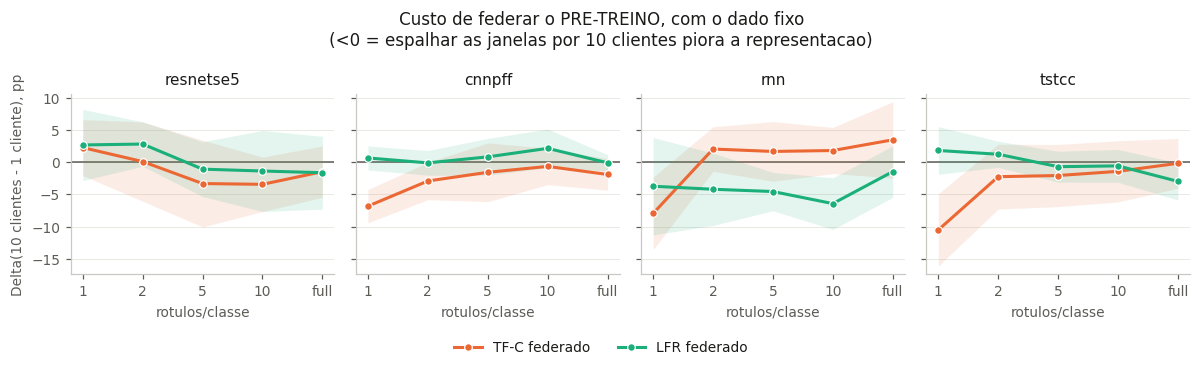

fed   cen  delta
method encoder                     
tfc    resnetse5  72.5  73.6   -1.2
       cnnpff     75.6  78.4   -2.8
       rnn        76.9  76.7    0.2
       tstcc      70.0  73.3   -3.3
lfr    resnetse5  74.6  74.3    0.3
       cnnpff     71.6  70.9    0.7
       rnn        62.3  66.4   -4.1
       tstcc      71.9  72.2   -0.2

In [12]:
ESPERADO = len(SSL) * len(ENCODERS) * len(SIMPLE) * len(ALL_SHOTS) * 4   # = 320 runs

if xsingle.empty:
    print('Exp. 2 ainda nao produziu nenhum parcial. Nada a plotar.')
else:
    cel = xsingle.groupby(KEY + ['target']).ngroups
    print(f'Exp. 2: {cel} de {ESPERADO} celulas ({cel / ESPERADO:.0%}).')

if not xsingle.empty and cel == ESPERADO:
    # Pareado no run: o mesmo encoder, spec, seed, degrau e alvo dos dois lados.
    fed = plato(raw[raw.method.isin(SSL) & raw.spec.isin(SIMPLE)]).rename('fed')
    cen = plato(xsingle).rename('cen')
    e2 = pd.concat([fed, cen], axis=1).dropna()
    e2['delta'] = e2['fed'] - e2['cen']

    fig, axes = plt.subplots(1, len(ENCODERS), sharey=True, figsize=(11, 3.0))
    x = np.arange(len(ALL_SHOTS))
    for ax, enc in zip(axes, ENCODERS):
        style(ax)
        for m in SSL:
            g = (e2.xs(m, level='method').xs(enc, level='encoder')
                   .groupby('n_shots')['delta'].agg(['mean', 'std']).reindex(ALL_SHOTS))
            ax.plot(x, g['mean'], color=CM[m], lw=2, marker='o', ms=5, mec='white',
                    mew=0.8, label=LABEL[m], zorder=3)
            ax.fill_between(x, g['mean'] - g['std'], g['mean'] + g['std'],
                            color=CM[m], alpha=0.12, lw=0, zorder=2)
        ax.axhline(0, color=INK2, lw=1, zorder=1)
        ax.set_xticks(x); ax.set_xticklabels(ALL_SHOTS)
        ax.set_title(enc, fontsize=10, color=INK)
        ax.set_xlabel('rotulos/classe')
    axes[0].set_ylabel('Delta(10 clientes - 1 cliente), pp')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.10))
    fig.suptitle('Custo de federar o PRE-TREINO, com o dado fixo\n'
                 '(<0 = espalhar as janelas por 10 clientes piora a representacao)',
                 fontsize=11)
    fig.tight_layout(); plt.show()

    display(e2.groupby(['method', 'encoder'])[['fed', 'cen', 'delta']].mean()
              .reindex([(m, e) for m in SSL for e in ENCODERS]).round(1))
elif not xsingle.empty:
    print('Grade incompleta — nao se compara media sobre celulas faltantes. '
          'Acompanhe com: tail -f logs/fedssl_exp2.log')

---

## 9. Existe um efeito do "SSL", ou só efeitos de pares?

O §5 mostrou que `A` e `DiD` variam bastante de célula para célula. Esta seção
pergunta se essa variação é **estrutura** — pares (método SSL + encoder) que de fato
diferem — ou **ruído de seed**, e transforma a resposta em teste.

### 9.0 A hipótese, e por que ela é uma só

A tentação é escrever duas hipóteses complementares: *"o SSL ajuda contra domain
shift"* e *"o SSL não ajuda"*. Elas não são complementares, são **P e ¬P** — e
"mostrar as duas" é mostrar que a evidência não decide. Pior: com 64 células e 4
seeds, sempre haverá células positivas e negativas; exibi-las como confirmação de
ambas é exatamente o p-hacking que o §10.1 proíbe.

A hipótese que sobrevive à formulação é **uma**:

> **H:** o ganho do SSL sobre o supervisionado depende do par (método, encoder) —
> não existe um efeito do "SSL".
>
> **Nula:** todos os pares compartilham o mesmo efeito; o que varia entre eles é seed.

O teste é direto: comparar a variância **entre** as médias dos pares contra a
variância **entre seeds dentro** de cada célula. Se a primeira não superar a
segunda, a nula fica de pé e "quais pares ajudam" não tem resposta nestes dados.

### 9.0.1 Por que o eixo principal é `A`, e não `DiD`

São perguntas diferentes, e a distinção já está no §5:

- **`A` é a pergunta de deployment** — *"vou operar uma federação cross-domain; o
  SSL me ajuda?"* Não precisa de controle.
- **`DiD` é a pergunta mecanística** — *"o SSL ataca o shift especificamente?"*

`A` responde a primeira e **não** autoriza a segunda: um `A` alto com `B` igualmente
alto significa que o SSL conserta o encoder, não o shift.

**Cada barra da 9.1 é uma federação, não uma média de federações.** Os dois
`in10` são experimentos separados — um treinado nos 10 usuários do RealWorld_thigh,
outro nos 10 do MotionSense — e aparecem como `RW_in10` e `MS_in10`. Os níveis dos
dois alvos são muito diferentes (~65% contra ~85%), então qualquer média entre eles
esconde mais do que resume. A linha vertical separa os dois blocos de alvo.

**As figuras mostram nível; as tabelas e o §9.3 mostram o Δ.** Barra de acurácia
absoluta é o que se lê sem explicação: se a barra do LFR ou do TF-C passa a do
supervisionado, aquele par ajuda naquela condição. O Δ, o dp de seed e o teste da
nula vêm logo abaixo de cada figura, em número — que é onde eles se defendem
melhor do que numa geometria.

**Recorte:** degraus 1/2/5/10/`full`, 2 alvos, 4 seeds = **40 células-seed por par**.
O `full` entra pela junção descrita na §4.2 — o braço supervisionado vem de
`fed_cross_device.csv`, mesmo protocolo mas outro mutirão, pareado por seed. Como
`A` e `DiD` são **diferenças**, a troca de fonte entra nos dois termos do Δ e tende
a se cancelar; ainda assim, um resultado que dependesse só do `full` deveria ser
tratado como mais frágil que os demais degraus.

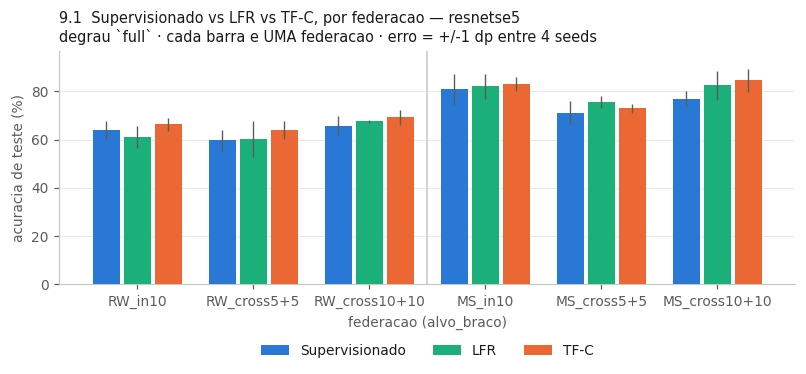

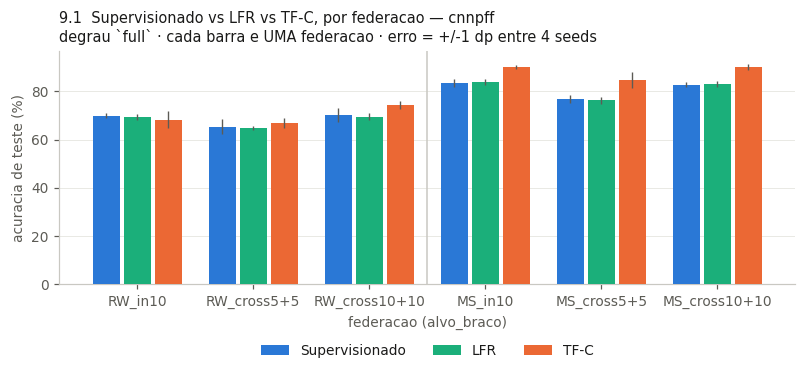

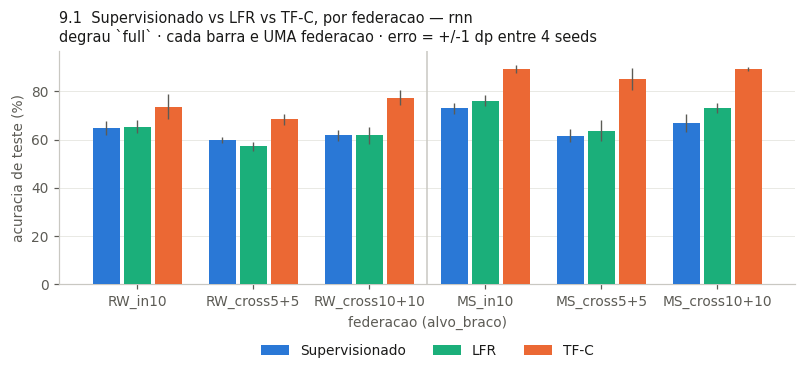

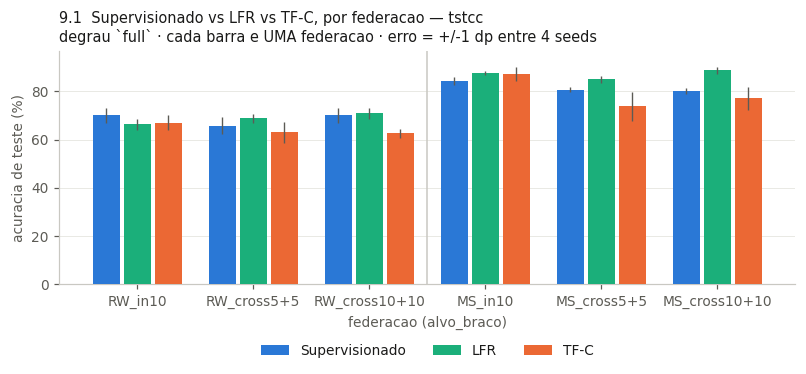

Acuracia (%) no degrau `full`, por federacao:


Supervisionado   LFR  TF-C
encoder   grupo                                    
resnetse5 RW_in10                  63.9  61.3  66.4
          RW_cross5+5              59.8  60.2  64.0
          RW_cross10+10            65.8  67.6  69.2
          MS_in10                  80.9  82.1  83.0
          MS_cross5+5              71.0  75.6  73.0
          MS_cross10+10            77.0  82.5  84.5
cnnpff    RW_in10                  70.0  69.4  68.3
          RW_cross5+5              65.4  64.7  67.0
          RW_cross10+10            70.4  69.5  74.5
          MS_in10                  83.5  84.0  90.2
          MS_cross5+5              76.8  76.3  84.7
          MS_cross10+10            82.9  83.1  90.1
rnn       RW_in10                  64.9  65.5  73.7
          RW_cross5+5              60.0  57.3  68.4
          RW_cross10+10            61.8  61.8  77.4
          MS_in10                  73.0  76.2  89.3
          MS_cross5+5              61.7  63.7  85.3
          MS_cross10+10            66.9  73.1  89.2
tstcc     RW_in10                  70.2  66.5  67.1
          RW_cross5+5              65.8  69.0  63.0
          RW_cross10+10            70.0  71.0  62.7
          MS_in10                  84.3  87.8  87.1
          MS_cross5+5              80.8  85.1  73.8
          MS_cross10+10            80.2  88.7  77.2

Os mesmos dados como Delta, por par (pp) — dp de seed: A 4.7 pp, DiD 5.8 pp


,A,A_dp,A_pos,DiD,n
par,,,,,
tfc + rnn,20.3,6.6,100.0,-0.5,40
tfc + cnnpff,3.4,4.3,72.5,-0.8,40
lfr + tstcc,2.6,3.5,72.5,0.3,40
lfr + resnetse5,2.3,5.2,65.0,-0.4,40
tfc + resnetse5,1.2,6.3,55.0,0.6,40
lfr + rnn,0.9,4.5,57.5,-5.3,40
lfr + cnnpff,-0.3,1.7,42.5,-0.4,40
tfc + tstcc,-2.1,6.5,32.5,-2.5,40


In [13]:
LAB3 = {'none': 'Supervisionado', 'lfr': 'LFR', 'tfc': 'TF-C'}
ORDEM_BARRA = ['none', 'lfr', 'tfc']
TAG = {'RealWorld_thigh': 'RW', 'MotionSense': 'MS'}

def base_por_seed():
    """Acuracia (%) por (encoder, method, braco, alvo, degrau, seed) — sem mediar nada.

    Quem agrega e cada figura, porque as duas agregacoes possiveis NAO sao a mesma
    coisa: `in10` sao DUAS federacoes distintas (uma treinada nos 10 usuarios do
    RealWorld_thigh, outra nos 10 do MotionSense), enquanto `cross5+5` e
    `cross10+10` sao UMA federacao avaliada em dois alvos. Mediar a primeira funde
    experimentos diferentes — foi o erro da versao anterior desta figura; mediar a
    segunda apenas resume a propria federacao.

    O braco supervisionado no degrau `full` vem de fed_cross_device.csv (ver §4.2)."""
    a = sel.copy()
    b = pd.read_csv(BASE_CSV)
    b = b[(b.local_epochs == 5) & (b['round'] > b['round'].max() - PLATEAU)
          & b.spec.isin(ARM)]
    b = (b.groupby(['encoder', 'spec', 'target', 'seed'])['test_acc'].mean()
         .reset_index().assign(method='none', n_shots='full'))
    a = pd.concat([a, b.assign(arm=b.spec.map(ARM))], ignore_index=True)
    a['braco'] = a.arm.map(BRACO)
    a['test_acc'] *= 100
    return (a.groupby(['encoder', 'method', 'braco', 'target', 'n_shots',
                       'seed'])['test_acc'].mean().reset_index())

PS = base_por_seed()

def stats(df, col):
    """mean/std ENTRE SEEDS — a barra de erro nunca carrega diferenca entre alvos."""
    return df.groupby(['encoder', 'method', col])['test_acc'].agg(['mean', 'std'])

def barras(tab, grupos, titulo, sub, xlabel, divisor=None, larg=6.0):
    """UMA figura por encoder; em cada grupo, 3 barras: SL / LFR / TF-C.

    `tab` vem indexada por (encoder, method, grupo) — o que conta como grupo e
    decisao da celula que chama, nao desta funcao. O `ylim` e COMUM as quatro
    figuras, calculado antes do laco: sem isso cada uma escolheria a propria escala
    e comparar encoders entre figuras viraria erro de leitura garantido. O eixo y
    comeca em ZERO porque barra codifica magnitude pelo comprimento."""
    x, w = np.arange(len(grupos)), 0.8 / len(ORDEM_BARRA)
    topo = max(np.nansum([tab['mean'].get((e, m, g), np.nan),
                          tab['std'].get((e, m, g), 0)])
               for e in ENCODERS for m in ORDEM_BARRA for g in grupos)
    for enc in ENCODERS:
        fig, ax = plt.subplots(figsize=(larg, 3.6))
        style(ax)
        for k, m in enumerate(ORDEM_BARRA):
            mu = [tab['mean'].get((enc, m, g), np.nan) for g in grupos]
            sd = [tab['std'].get((enc, m, g), np.nan) for g in grupos]
            # w*0.88 deixa o vao de superficie entre barras adjacentes
            ax.bar(x + (k - 1) * w, mu, w * 0.88, color=CM[m], label=LAB3[m],
                   yerr=sd, error_kw=dict(ecolor=INK2, lw=0.9, capsize=0), zorder=3)
        if divisor is not None:
            ax.axvline(divisor, color='#c9c8c2', lw=1, zorder=1)
        ax.set_xticks(x); ax.set_xticklabels(grupos)
        ax.set_ylim(0, topo * 1.06)
        ax.set_ylabel('acuracia de teste (%)')
        ax.set_xlabel(xlabel)
        ax.set_title(f'{titulo} — {enc}\n{sub}', fontsize=9.5, loc='left', color=INK)
        ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.20))
        fig.tight_layout()
        plt.show()

d91 = PS[PS.n_shots == 'full'].copy()
d91['grupo'] = d91.target.map(TAG) + '_' + d91.braco
acc91 = stats(d91, 'grupo')
G91 = [f'{t}_{b}' for t in ('RW', 'MS') for b in BRACOS]

barras(acc91, G91, '9.1  Supervisionado vs LFR vs TF-C, por federacao',
       'degrau `full` · cada barra e UMA federacao · erro = +/-1 dp entre 4 seeds',
       'federacao (alvo_braco)', divisor=2.5, larg=7.4)

print('Acuracia (%) no degrau `full`, por federacao:')
display(pd.concat({LAB3[m]: acc91.xs(m, level='method')['mean'] for m in ORDEM_BARRA},
                  axis=1).reindex([(e, g) for e in ENCODERS for g in G91]).round(1))

def pares_long():
    """A, B e DiD por (par, alvo, degrau, seed) — insumo do §9.3.

    Reusa `dssl` da §4.2, que ja e a fonte unica do Delta(SSL - SL): A e o Delta no
    braco cross5+5 e B o Delta no braco in-domain DO MESMO alvo. Indexar por alvo
    escolhe sozinho o in10 certo, porque cada spec in-domain rende um alvo so — e
    por isso o §9.3 nunca sofreu do problema que a figura 9.1 tinha."""
    ix = ['encoder', 'metodo', 'target', 'n_shots', 'seed']
    A = dssl[dssl.arm == 'cross5+5'].set_index(ix)['delta']
    B = dssl[dssl.braco == 'in10'].set_index(ix)['delta']
    i = A.index.intersection(B.index)
    r = pd.DataFrame({'A': A.loc[i], 'B': B.loc[i]}).reset_index()
    r['DiD'] = r.A - r.B
    r['par'] = r.metodo + ' + ' + r.encoder
    return r.rename(columns={'target': 'alvo'})

pares = pares_long()
ORDEM = pares.groupby('par')['A'].mean().sort_values(ascending=False).index.tolist()

def ruido_seed(col):
    """dp entre seeds DENTRO da celula (par, alvo, degrau) — a escala do acaso."""
    return float(np.sqrt(pares.groupby(['par', 'alvo', 'n_shots'])[col].std().pow(2).mean()))

print('Os mesmos dados como Delta, por par (pp) — dp de seed: '
      'A %.1f pp, DiD %.1f pp' % (ruido_seed('A'), ruido_seed('DiD')))
display(pares.groupby('par').agg(
    A=('A', 'mean'), A_dp=('A', 'std'), A_pos=('A', lambda s: (s > 0).mean() * 100),
    DiD=('DiD', 'mean'), n=('A', 'size')).reindex(ORDEM).round(1))


### 9.2 O mesmo ao longo do orçamento de rótulos

A 9.1 fixa o degrau `full`. Aqui o eixo x vira a ladder, com o braço fixo em
`cross5+5` — o cenário de domain shift, que é o da hipótese. Um par que só ajuda
num degrau é candidato a acaso de amostragem; um que ajuda nos cinco, não.

**Os alvos também aparecem separados aqui**, em dois blocos divididos pela linha
vertical. `cross5+5` é **uma** federação avaliada em dois conjuntos de teste — não
duas federações como era o `in10` da 9.1 —, mas os dois alvos vivem em patamares
diferentes (~15 pp), e a média achatava justamente a assimetria que o §5 mostra ser
o achado mais interessante da grade: o custo do shift não é o mesmo nos dois lados.

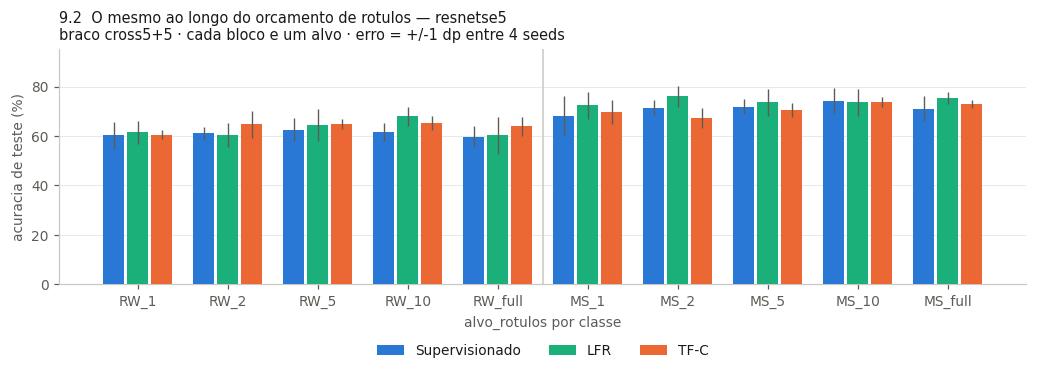

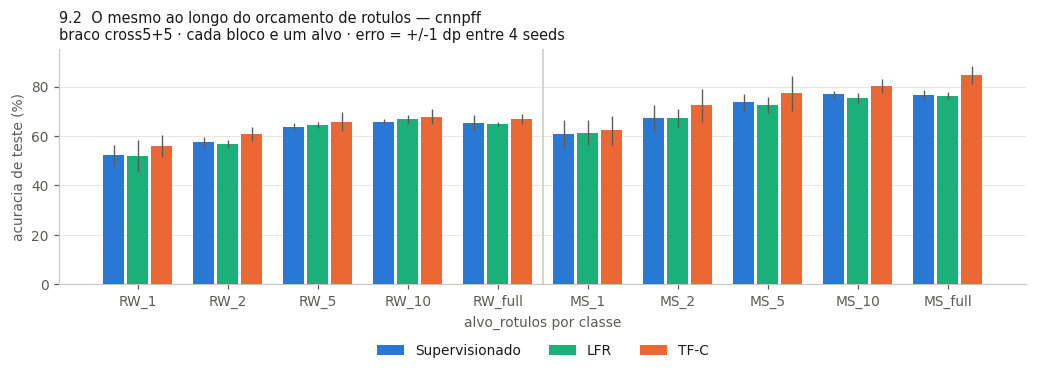

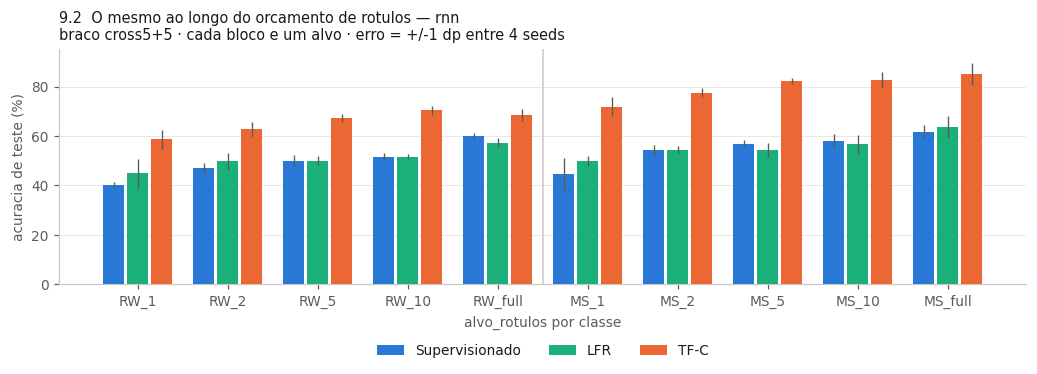

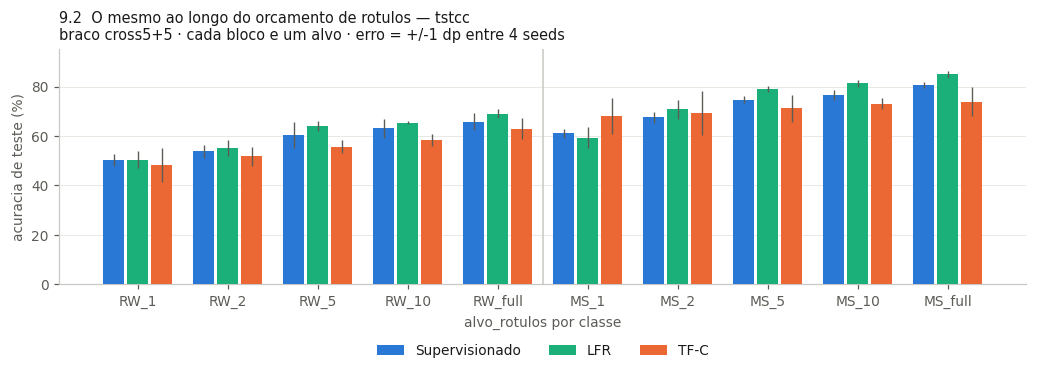

Acuracia (%) no braco cross5+5, por alvo e degrau:


Supervisionado   LFR  TF-C
encoder   grupo                              
resnetse5 RW_1               60.2  61.5  60.4
          RW_2               61.1  60.4  64.7
          RW_5               62.6  64.3  64.9
          RW_10              61.7  67.9  65.4
          RW_full            59.8  60.2  64.0
          MS_1               68.3  72.4  69.8
          MS_2               71.4  76.1  67.5
          MS_5               71.8  73.6  70.5
          MS_10              74.3  73.6  73.6
          MS_full            71.0  75.6  73.0
cnnpff    RW_1               52.2  51.8  55.8
          RW_2               57.4  56.8  61.0
          RW_5               63.8  64.4  65.8
          RW_10              65.8  66.7  67.9
          RW_full            65.4  64.7  67.0
          MS_1               60.9  61.4  62.2
          MS_2               67.2  67.3  72.4
          MS_5               73.6  72.5  77.3
          MS_10              76.9  75.4  80.2
          MS_full            76.8  76.3  84.7
rnn       RW_1               40.1  44.9  58.7
          RW_2               47.0  49.8  62.8
          RW_5               50.0  50.0  67.2
          RW_10              51.7  51.7  70.3
          RW_full            60.0  57.3  68.4
          MS_1               44.6  49.8  71.9
          MS_2               54.2  54.5  77.5
          MS_5               57.0  54.4  82.4
          MS_10              58.1  56.7  82.9
          MS_full            61.7  63.7  85.3
tstcc     RW_1               50.2  50.5  48.1
          RW_2               53.7  55.1  51.8
          RW_5               60.4  64.1  55.7
          RW_10              63.2  65.4  58.3
          RW_full            65.8  69.0  63.0
          MS_1               61.1  59.3  68.1
          MS_2               67.5  70.8  69.4
          MS_5               74.8  79.1  71.2
          MS_10              76.5  81.3  73.1
          MS_full            80.8  85.1  73.8

In [14]:
# Agora tambem separado por alvo, como a 9.1. `cross5+5` e UMA federacao, mas os
# dois alvos vivem em patamares diferentes (~15 pp), e mediar os dois achatava isso.
d92 = PS[PS.braco == 'cross5+5'].copy()
d92['grupo'] = d92.target.map(TAG) + '_' + d92.n_shots
acc92 = stats(d92, 'grupo')
G92 = [f'{t}_{s}' for t in ('RW', 'MS') for s in ALL_SHOTS]

barras(acc92, G92, '9.2  O mesmo ao longo do orcamento de rotulos',
       'braco cross5+5 · cada bloco e um alvo · erro = +/-1 dp entre 4 seeds',
       'alvo_rotulos por classe', divisor=4.5, larg=9.5)

print('Acuracia (%) no braco cross5+5, por alvo e degrau:')
display(pd.concat({LAB3[m]: acc92.xs(m, level='method')['mean'] for m in ORDEM_BARRA},
                  axis=1).reindex([(e, g) for e in ENCODERS for g in G92]).round(1))


### 9.3 O teste explícito

A figura mostra; a tabela decide. `var_entre_pares` é a variância das 8 médias de
par; `var_ruido_seed` é a variância entre seeds dentro da célula (par, alvo,
degrau) — a escala do acaso neste desenho.

A segunda linha de cada métrica repete a conta **sem o `tfc + rnn`**. Não é para
esconder o par: é para saber se a heterogeneidade é um padrão ou é ele.

In [15]:
def decomposicao(r, col):
    dentro = r.groupby(['par', 'alvo', 'n_shots'])[col].std().pow(2).mean()
    entre = r.groupby('par')[col].mean().var()
    return pd.Series({'var_entre_pares': entre, 'var_ruido_seed': dentro,
                      'razao': entre / dentro})

linhas = {}
for col in ('A', 'DiD'):
    linhas[(col, 'grade completa')] = decomposicao(pares, col)
    linhas[(col, 'sem tfc+rnn')] = decomposicao(pares[pares.par != 'tfc + rnn'], col)
dec = pd.DataFrame(linhas).T.round(2)
dec.index.names = ['metrica', 'recorte']
print('\nHeterogeneidade entre pares vs ruido de seed (pp^2).')
print('razao > 1 = os pares diferem alem do acaso; < 1 = a variacao aparente e seed.')
print(dec.to_string())



Heterogeneidade entre pares vs ruido de seed (pp^2).
razao > 1 = os pares diferem alem do acaso; < 1 = a variacao aparente e seed.
                        var_entre_pares  var_ruido_seed  razao
metrica recorte                                               
A       grade completa            48.99           22.15   2.21
        sem tfc+rnn                3.59           22.68   0.16
DiD     grade completa             3.73           33.74   0.11
        sem tfc+rnn                4.28           34.97   0.12


### 9.4 Veredito

**A hipótese se sustenta — mas por um par só, e isso muda o que se pode afirmar.**

**Δ A tem heterogeneidade real, e ela é inteiramente o `tfc + rnn`.** A razão
entre-pares/ruído cai de **2,21 para 0,16** quando esse par sai — praticamente a
razão do DiD, que é ruído puro. Os outros sete pares são um bloco indistinguível:
todos dentro da faixa de ±1 dp de seed (4,7 pp), com médias entre −2,1 e +3,4 pp e
frações de células positivas entre 33% e 73%, isto é, perto de cara-ou-coroa.

**O que responde "quais pares ajudam":**

| | par | leitura |
|---|---|---|
| **ajuda** | `tfc + rnn` | **+20,3 pp**, positivo em **100%** das 40 células-seed, estável nos cinco degraus (+16,0 a +22,9). É o único par que escapa do ruído. |
| **atrapalha (candidato)** | `tfc + tstcc` | −2,1 pp na média, mas **−4,1 / −4,1 / −4,9 pp** nos degraus 5, 10 e `full`, onde sai da faixa pelo lado negativo. O dano aparece **com** rótulo, não sem ele — em 1-shot ele é +2,4. |
| **indistinguíveis** | os outros seis | dentro da faixa em todos os degraus. Ordená-los entre si é ordenar ruído. |

**O `tfc + rnn` não é "o TF-C é ótimo".** A `rnn` é o pior baseline da grade; o que
o número diz é que **o TF-C resgata o pior encoder**, e é assim que ele deve ser
citado (a mesma ressalva está em `fedssl_cross_device_rnn.ipynb`). Um resgate desse
tamanho é resultado — mas é resultado sobre a interação, não sobre o método. A §4.2
mostra o mesmo padrão nos três braços, o que reforça que é o par, não o cenário.

**DiD: nenhum par mitiga o shift, e não há heterogeneidade a explicar.** Todos os
oito dentro da faixa de ruído (5,8 pp), médias entre −5,3 e +0,6 pp, razão 0,11 com
ou sem o `tfc + rnn`. **Este é um resultado negativo declarado, não uma hipótese
fracassada:** a motivação original do projeto afirma que o SSL ataca a
heterogeneidade de domínio, e nesta base ele não ataca — nem no par que mais ajuda
no Δ A.

**Consequência para a fila de perguntas.** "Quais pares ajudam e por quê" é
respondível: há um par, e a pergunta de mecanismo vira *por que o TF-C resgata a
`rnn` e não o `tstcc`* — dois encoders, o mesmo método, sinais opostos. Já "como
escolher o par" precisa de cuidado: escolher o melhor par na mesma grade em que ele
foi medido é circular, e exigiria alvo ou seed retido para virar afirmação.

## 10. Ressalvas — ler antes de citar qualquer número daqui

1. **Correções múltiplas.** São 64 células de A e 64 de DiD (4 encoders × 2 alvos ×
   2 métodos × 4 degraus), cada uma com 4 seeds. Escolher a mais favorável e reportá-la
   é p-hacking. Só o agregado por encoder sustenta afirmação; a tabela por célula é
   exploratória e serve para gerar hipótese, não para confirmá-la.
2. **Dinâmica de menos no eixo de domínio.** O custo do shift no baseline vai de −0,7 a
   −9,8 pp, e só **um** par (resnetse5 / MotionSense) passa de −5. Com um ponto de alto
   custo, nem "mitiga" nem "não mitiga" é sustentável — é ausência de evidência, não
   evidência de ausência. O par cintura↔perna da segunda onda tem gap maior.
3. **F7.** Seleção few-shot na validação cheia (ver topo). Afeta todos os braços
   igualmente, então provavelmente não inverte um Δ — mas infla o nível absoluto.
4. **O `cross10+10` não é "dado estrangeiro vale tanto quanto dado próprio".** Ele tem
   20 clientes contra 10 do `in10-RW`; não existe federação de 20 clientes só de
   RW_thigh (a base tem 10 usuários). O Δ é "acrescentar um segundo domínio".
5. **O §7 só cobre os dois braços in-domain.** `cross5+5` e `cross10+10` não têm par
   cruzado: pré-treinar "no outro domínio" não é definível para um spec que já mistura
   os dois. A conclusão do §7 vale para os alvos simples, não para a grade toda.
6. **A retenção do §7 não é interpretável onde o ganho é pequeno.** Onde `próprio` está
   perto de zero, a razão `outro/próprio` explode ou troca de sinal sem significar nada
   — por isso a tabela mostra os dois Δ e o custo em pp, não a razão. A leitura
   defensável é sobre as células de ganho grande (TF-C/`rnn`), não sobre a média.
7. **O §8 é sobre o *pré-treino*, não sobre o sistema.** O `single:` concentra as
   janelas do pré-treino num cliente só; o fine-tuning continua federado nos 10. Ele
   **não** é o skyline centralizado do pipeline inteiro, e não deve ser citado como
   "quanto se perde por federar" sem essa qualificação.
8. **O degrau `full` vem de duas grades.** O lado SSL sai desta grade; o supervisionado, de `fed_cross_device.csv` (`local_epochs == 5`). Mesmo protocolo — R=150, budget 192, seeds 0–3 — mas outro mutirão. Vale para a §4.2 e para todo o §9. Em Δ a troca de fonte entra nos dois termos e tende a se cancelar; em **nível** absoluto, não.
